In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score  

df = pd.read_csv(r"C:\Users\ninja\Downloads\Data Science Jobs Salaries.csv")
df.head()
df.shape
df.describe()


,salary,salary_in_usd,remote_ratio
count,2.450000e+02,245.000000,245.000000
mean,5.025418e+05,99868.012245,69.183673
std,2.276230e+06,83983.326949,37.593421
min,4.000000e+03,2876.000000,0.000000
25%,6.000000e+04,45896.000000,50.000000
50%,1.030000e+05,81000.000000,100.000000
75%,1.740000e+05,130000.000000,100.000000
max,3.040000e+07,600000.000000,100.000000


In [176]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [177]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [178]:
df['job_title'] = df['job_title'].str.strip()

In [179]:
print(df["job_title"].value_counts().head(10))

job_title
Data Scientist               59
Data Engineer                38
Machine Learning Engineer    20
Data Analyst                 20
Research Scientist           10
Data Science Consultant       7
Big Data Engineer             6
BI Data Analyst               5
Lead Data Engineer            5
AI Scientist                  5
Name: count, dtype: int64


In [180]:
# creat new cell

top_jobs = ["Data Scientist","Data Engineer","Machine Learning Engineer","Data Analyst"]

df = df[df["job_title"].isin(top_jobs)]
print("New data size:",df.shape)
print("\n:")
print(df['job_title'].value_counts())

New data size: (137, 11)

:
job_title
Data Scientist               59
Data Engineer                38
Machine Learning Engineer    20
Data Analyst                 20
Name: count, dtype: int64


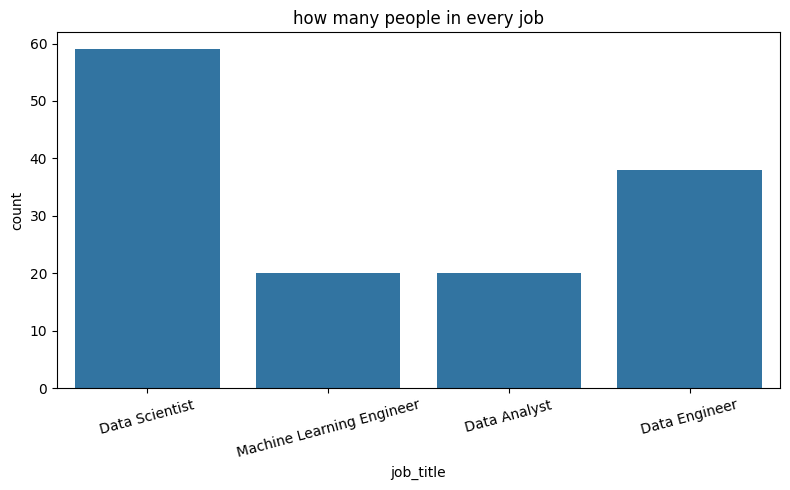

In [181]:
# graph 
plt.figure(figsize=(8,5)),sns.countplot(data=df,x="job_title")
plt.title("how many people in every job")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

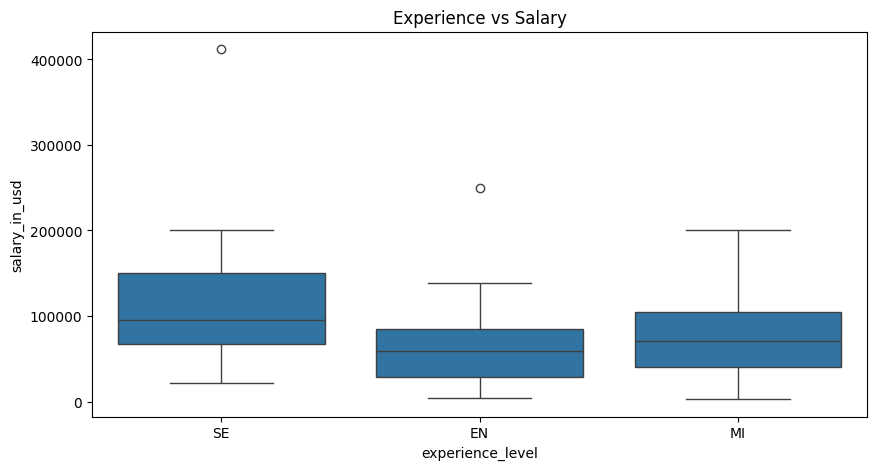

In [182]:
# Experience level kitna affect karta hai salary ko?
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='experience_level', y='salary_in_usd')
plt.title('Experience vs Salary')
plt.show()

In [183]:
df['work_year'] = df['work_year'].astype(str).str.replace('e', '', regex=False)
df['work_year'] = df['work_year'].astype(int)

In [185]:
# encoding the text and columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


text_columns = ['experience_level', 'employment_type', 
                'employee_residence', 'company_location', 
                'company_size']
for col in text_columns:
    df[col] = le.fit_transform(df[col])


# taret encode kro
le = LabelEncoder()
y_encoded = le_target.fit_transform(df["job_title"])
print("Job Titles:")

for i ,name in enumerate(le_target.classes_):
     print(f"  {name}  {i}")

Job Titles:
  Data Analyst  0
  Data Engineer  1
  Data Scientist  2
  Machine Learning Engineer  3


In [186]:
x = df[['experience_level', 'employment_type', 'salary_in_usd', 
        'remote_ratio', 'company_size', 'work_year','employee_residence', 'company_location']]


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print("Training data :",x_train.shape)
print("Testing data :",x_test.shape)

Training data : (109, 8)
Testing data : (28, 8)


In [187]:
# creat model and train
model = RandomForestClassifier(n_estimators= 200,random_state=42)
model.fit(x_train,y_train)

print("model has been  trained ")

# test kro
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",round(accuracy *100,2),"%")

model has been  trained 
Accuracy : 35.71 %


In [188]:
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


Detailed Report:
                           precision    recall  f1-score   support

             Data Analyst       0.33      0.20      0.25         5
            Data Engineer       0.38      0.33      0.35         9
           Data Scientist       0.38      0.60      0.46        10
Machine Learning Engineer       0.00      0.00      0.00         4

                 accuracy                           0.36        28
                macro avg       0.27      0.28      0.27        28
             weighted avg       0.31      0.36      0.32        28



In [192]:
joblib.dump(model, 'job_classifier_model.pkl')
joblib.dump(le_target, 'label_encoder.pkl')
print("\nmodel has been saved")


model has been saved


In [16]:
import os
print(os.getcwd())



C:\Users\ninja
